# Datathon Passos Mágicos — Notebook 03: Modelo Preditivo

**Objetivo:** Construir um modelo de Machine Learning para prever a **probabilidade de um aluno entrar em risco de defasagem** (`EM_RISCO`).

**Variável-alvo:** `EM_RISCO = 1` quando o aluno tem Pedra == QUARTZO ou Defasagem > 0.

**Algoritmo:** Random Forest (classificação)

---
### Etapas
1. Feature Engineering
2. Separação Treino/Teste
3. Modelagem Preditiva (Random Forest)
4. Avaliação dos Resultados
5. Export do Modelo


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

BASE = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH   = os.path.join(BASE, '..', 'data')
MODELS_PATH = os.path.join(BASE, '..', 'models')
os.makedirs(MODELS_PATH, exist_ok=True)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 1. Feature Engineering

Criamos novas features derivadas dos indicadores para enriquecer o modelo.

In [2]:
df = pd.read_csv(os.path.join(DATA_PATH, 'pede_consolidado.csv'))

print(f'Dataset bruto: {df.shape}')

# ── Features base ───────────────────────────────────────────────────
FEATURES_BASE = ['Fase', 'INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']

# IPP tem 34% de nulos → incluímos mas com imputação
FEATURES_BASE.append('IPP')

# ── Feature Engineering ─────────────────────────────────────────────
df['FE_IEG_x_IDA']    = df['IEG'] * df['IDA']           # interação engajamento × desempenho
df['FE_Delta_IAA_IDA']= df['IAA'] - df['IDA']           # superestimação
df['FE_IPS_baixo']    = (df['IPS'] < 5.0).astype(float) # flag psicossocial
df['FE_IEG_baixo']    = (df['IEG'] < 5.0).astype(float) # flag desengajado
df['FE_IDA_baixo']    = (df['IDA'] < 5.0).astype(float) # flag performance baixa
df['FE_Tres_baixos']  = df['FE_IPS_baixo'] + df['FE_IEG_baixo'] + df['FE_IDA_baixo']  # acumulado de flags
df['FE_IAN_defas']    = (df['IAN'] < 10.0).astype(float) # qualquer defasagem

FEATURES_ENG = [
    'FE_IEG_x_IDA', 'FE_Delta_IAA_IDA', 'FE_IPS_baixo',
    'FE_IEG_baixo', 'FE_IDA_baixo', 'FE_Tres_baixos', 'FE_IAN_defas'
]

ALL_FEATURES = FEATURES_BASE + FEATURES_ENG
TARGET = 'EM_RISCO'

# Dataset final
df_model = df[ALL_FEATURES + [TARGET]].copy()
df_model = df_model.dropna(subset=[f for f in ALL_FEATURES if f != 'IPP'] + [TARGET])

print(f'\nDataset para modelagem: {df_model.shape}')
print(f'Features: {len(ALL_FEATURES)}')
print(f'\nBalanceamento da variável-alvo:')
vc = df_model[TARGET].value_counts()
for cls, cnt in vc.items():
    print(f'  {cls} ({"EM RISCO" if cls==1 else "Sem risco"}): {cnt:,} ({cnt/len(df_model)*100:.1f}%)')

print('\n✅ Features criadas:')
for f in ALL_FEATURES:
    print(f'  {f}')

Dataset bruto: (3030, 64)

Dataset para modelagem: (2845, 17)
Features: 16

Balanceamento da variável-alvo:
  0 (Sem risco): 2,393 (84.1%)
  1 (EM RISCO): 452 (15.9%)

✅ Features criadas:
  Fase
  INDE
  IAA
  IEG
  IPS
  IDA
  IPV
  IAN
  IPP
  FE_IEG_x_IDA
  FE_Delta_IAA_IDA
  FE_IPS_baixo
  FE_IEG_baixo
  FE_IDA_baixo
  FE_Tres_baixos
  FE_IAN_defas


---
## 2. Separação Treino / Teste

In [3]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

# Separação estratificada: 80% treino / 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape[0]:,} registros')
print(f'Teste:  {X_test.shape[0]:,} registros')
print(f'\nBalanceamento no treino:')
print(y_train.value_counts(normalize=True).mul(100).round(1))
print(f'\nBalanceamento no teste:')
print(y_test.value_counts(normalize=True).mul(100).round(1))

Treino: 2,276 registros
Teste:  569 registros

Balanceamento no treino:
EM_RISCO
0   84.1000
1   15.9000
Name: proportion, dtype: float64

Balanceamento no teste:
EM_RISCO
0   84.2000
1   15.8000
Name: proportion, dtype: float64


---
## 3. Modelagem Preditiva — Random Forest

In [4]:
# Pipeline com imputação e Random Forest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Treino
pipeline.fit(X_train, y_train)

# Predições
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print('='*50)
print('       RANDOM FOREST — RESULTADOS')
print('='*50)
print(f'\nCross-Validation AUC-ROC (5-fold):')
print(f'  {cv_scores.round(4)}')
print(f'  Média: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nAUC-ROC no Teste: {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'\nRelatório de Classificação (threshold=0.5):')
print(classification_report(y_test, y_pred, target_names=['Sem risco', 'Em risco']))

       RANDOM FOREST — RESULTADOS

Cross-Validation AUC-ROC (5-fold):
  [0.9852 0.9687 0.9857 0.9737 0.9676]
  Média: 0.9762 ± 0.0078

AUC-ROC no Teste: 0.9733

Relatório de Classificação (threshold=0.5):
              precision    recall  f1-score   support

   Sem risco       0.97      0.96      0.97       479
    Em risco       0.80      0.87      0.83        90

    accuracy                           0.95       569
   macro avg       0.89      0.91      0.90       569
weighted avg       0.95      0.95      0.95       569



---
## 4. Avaliação dos Resultados

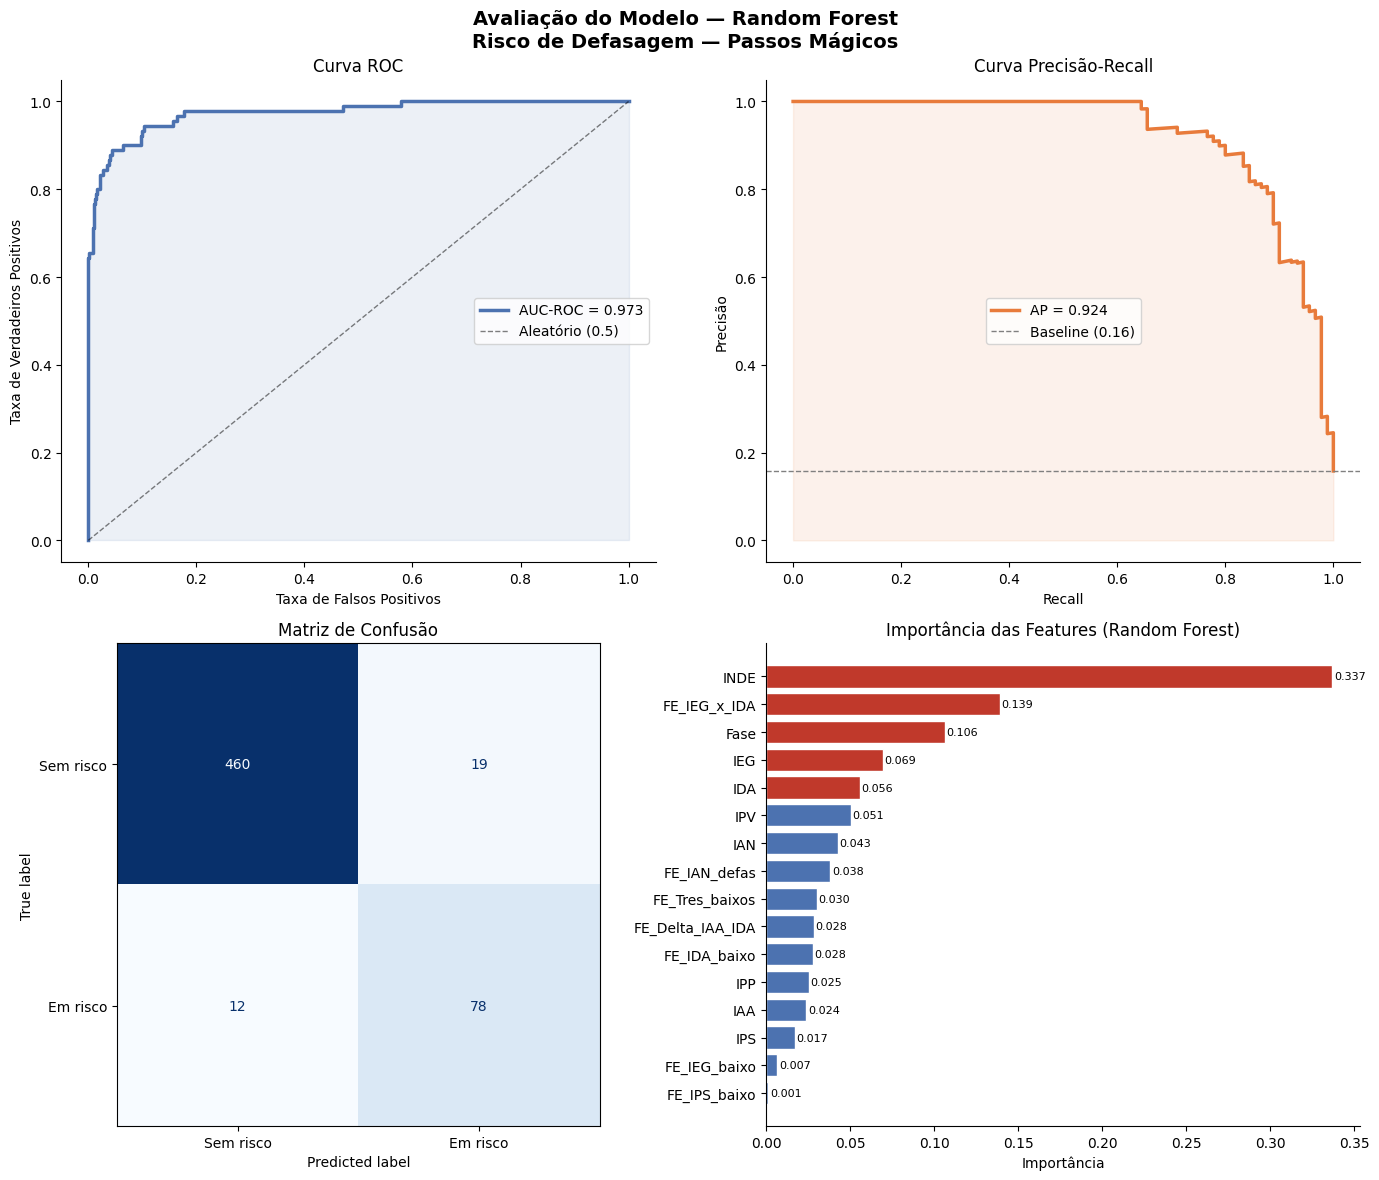


📊 Top 5 features mais importantes:
INDE           0.3368
FE_IEG_x_IDA   0.1392
Fase           0.1065
IEG            0.0693
IDA            0.0559
dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Avaliação do Modelo — Random Forest\nRisco de Defasagem — Passos Mágicos',
             fontsize=14, fontweight='bold')

# 4a — Curva ROC
ax = axes[0][0]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
ax.plot(fpr, tpr, color='#4C72B0', linewidth=2.5, label=f'AUC-ROC = {auc:.3f}')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aleatório (0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# 4b — Curva Precisão-Recall
ax = axes[0][1]
prec, rec, thresh = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)
ax.plot(rec, prec, color='#E87B3B', linewidth=2.5, label=f'AP = {ap:.3f}')
ax.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
ax.fill_between(rec, prec, alpha=0.1, color='#E87B3B')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisão')
ax.set_title('Curva Precisão-Recall', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# 4c — Matriz de Confusão
ax = axes[1][0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem risco', 'Em risco'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão', fontsize=12)

# 4d — Feature Importance
ax = axes[1][1]
rf = pipeline.named_steps['clf']
importances = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
cores_imp = ['#C0392B' if i >= len(importances) - 5 else '#4C72B0' for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values, color=cores_imp, edgecolor='white')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_title('Importância das Features (Random Forest)', fontsize=12)
ax.set_xlabel('Importância')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'modelo_avaliacao.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Top 5 features mais importantes:')
print(importances.tail(5)[::-1].round(4))

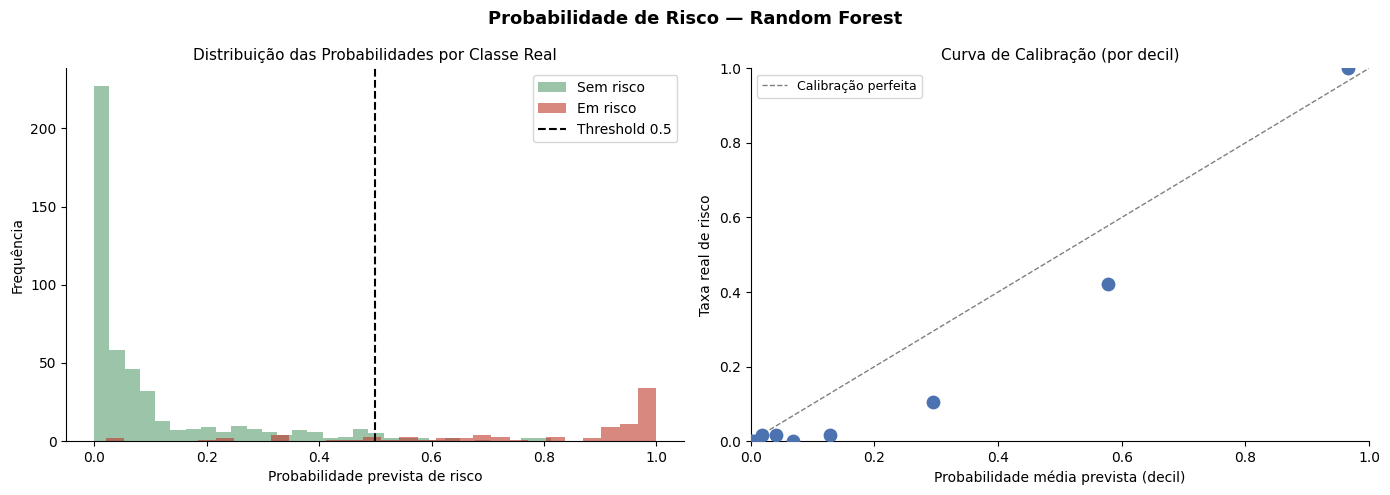

In [6]:
# Distribuição das probabilidades previstas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probabilidade de Risco — Random Forest', fontsize=13, fontweight='bold')

# Histograma separado por classe real
ax = axes[0]
prob_df = pd.DataFrame({'prob': y_pred_prob, 'real': y_test.values})
for cls, label, cor in [(0,'Sem risco','#5B9E6E'), (1,'Em risco','#C0392B')]:
    ax.hist(prob_df[prob_df['real']==cls]['prob'], bins=30, alpha=0.6,
            label=label, color=cor, edgecolor='none')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_xlabel('Probabilidade prevista de risco')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição das Probabilidades por Classe Real', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# Calibração — decis de probabilidade
ax = axes[1]
prob_df['decil'] = pd.qcut(prob_df['prob'], q=10, labels=False, duplicates='drop')
calib = prob_df.groupby('decil').agg(prob_media=('prob','mean'), taxa_real=('real','mean'))
ax.scatter(calib['prob_media'], calib['taxa_real'], color='#4C72B0', s=80, zorder=5)
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Calibração perfeita')
ax.set_xlabel('Probabilidade média prevista (decil)')
ax.set_ylabel('Taxa real de risco')
ax.set_title('Curva de Calibração (por decil)', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'modelo_probabilidades.png'), dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Análise por threshold ───────────────────────────────────────────
print('Análise por diferentes thresholds de decisão:')
print(f'{"Threshold":>10} | {"Precisão":>9} | {"Recall":>7} | {"F1":>7} | {"Alunos alertados":>17}')
print('-' * 60)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (y_pred_prob >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    if pred_t.sum() > 0:
        p = precision_score(y_test, pred_t, zero_division=0)
        r = recall_score(y_test, pred_t, zero_division=0)
        f = f1_score(y_test, pred_t, zero_division=0)
        n = pred_t.sum()
        print(f'{thresh:>10.1f} | {p:>9.3f} | {r:>7.3f} | {f:>7.3f} | {n:>17}')

print()
print('💡 Recomendação: threshold 0.4 maximiza recall (detectar mais alunos em risco)')
print('   threshold 0.5 equilibra precisão e recall')

Análise por diferentes thresholds de decisão:
 Threshold |  Precisão |  Recall |      F1 |  Alunos alertados
------------------------------------------------------------
       0.3 |     0.612 |   0.944 |   0.742 |               139
       0.4 |     0.711 |   0.900 |   0.794 |               114
       0.5 |     0.804 |   0.867 |   0.834 |                97
       0.6 |     0.910 |   0.789 |   0.845 |                78
       0.7 |     0.940 |   0.700 |   0.803 |                67

💡 Recomendação: threshold 0.4 maximiza recall (detectar mais alunos em risco)
   threshold 0.5 equilibra precisão e recall


---
## 5. Export do Modelo

In [8]:
# Salva o pipeline completo (imputer + modelo)
model_path = os.path.join(MODELS_PATH, 'random_forest_risco.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)
print(f'✅ Modelo salvo em: {model_path}')

# Salva lista de features para uso no Streamlit
features_path = os.path.join(MODELS_PATH, 'features.pkl')
with open(features_path, 'wb') as f:
    pickle.dump(ALL_FEATURES, f)
print(f'✅ Features salvas em: {features_path}')

# Verifica carregamento
with open(model_path, 'rb') as f:
    modelo_carregado = pickle.load(f)

# Teste de integridade
pred_check = modelo_carregado.predict_proba(X_test[:5])[:, 1]
print(f'\n✅ Modelo verificado. Probabilidades de risco (5 primeiros do teste):')
for i, prob in enumerate(pred_check):
    real = y_test.iloc[i]
    risco_label = '🔴 EM RISCO' if prob >= 0.5 else '🟢 Sem risco'
    print(f'  Aluno {i+1}: prob={prob:.3f} → {risco_label} (real: {"EM RISCO" if real==1 else "Sem risco"})')

print('\n' + '='*50)
print('       RESUMO DO MODELO')
print('='*50)
print(f'  Algoritmo:     Random Forest (300 árvores)')
print(f'  Features:      {len(ALL_FEATURES)}')
print(f'  Treino:        {len(X_train):,} registros')
print(f'  Teste:         {len(X_test):,} registros')
print(f'  AUC-ROC CV:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  AUC-ROC Teste: {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'  Modelo salvo:  {model_path}')

✅ Modelo salvo em: c:\Users\thiag\Desktop\POSTECH 5\passos_magicos\notebooks\..\models\random_forest_risco.pkl
✅ Features salvas em: c:\Users\thiag\Desktop\POSTECH 5\passos_magicos\notebooks\..\models\features.pkl

✅ Modelo verificado. Probabilidades de risco (5 primeiros do teste):
  Aluno 1: prob=0.256 → 🟢 Sem risco (real: Sem risco)
  Aluno 2: prob=0.957 → 🔴 EM RISCO (real: EM RISCO)
  Aluno 3: prob=0.008 → 🟢 Sem risco (real: Sem risco)
  Aluno 4: prob=0.009 → 🟢 Sem risco (real: Sem risco)
  Aluno 5: prob=1.000 → 🔴 EM RISCO (real: EM RISCO)

       RESUMO DO MODELO
  Algoritmo:     Random Forest (300 árvores)
  Features:      16
  Treino:        2,276 registros
  Teste:         569 registros
  AUC-ROC CV:    0.9762 ± 0.0078
  AUC-ROC Teste: 0.9733
  Modelo salvo:  c:\Users\thiag\Desktop\POSTECH 5\passos_magicos\notebooks\..\models\random_forest_risco.pkl


---
## Demo: Predição para um aluno hipotético

In [9]:
def prever_risco(fase, inde, iaa, ieg, ips, ida, ipv, ian, ipp=None):
    """Calcula probabilidade de risco para um aluno."""
    ipp_val = ipp if ipp is not None else np.nan
    entrada = {
        'Fase': fase, 'INDE': inde, 'IAA': iaa, 'IEG': ieg,
        'IPS': ips, 'IDA': ida, 'IPV': ipv, 'IAN': ian, 'IPP': ipp_val,
        'FE_IEG_x_IDA'    : ieg * ida,
        'FE_Delta_IAA_IDA': iaa - ida,
        'FE_IPS_baixo'    : float(ips < 5.0),
        'FE_IEG_baixo'    : float(ieg < 5.0),
        'FE_IDA_baixo'    : float(ida < 5.0),
        'FE_Tres_baixos'  : float(ips < 5.0) + float(ieg < 5.0) + float(ida < 5.0),
        'FE_IAN_defas'    : float(ian < 10.0),
    }
    X_novo = pd.DataFrame([entrada])[ALL_FEATURES]
    prob = modelo_carregado.predict_proba(X_novo)[0, 1]
    pred = 'EM RISCO 🔴' if prob >= 0.5 else 'Sem risco 🟢'
    return prob, pred

# Exemplos
print('DEMO — Predição de risco para alunos hipotéticos')
print('='*55)

casos = [
    {'nome': 'Aluno com bons indicadores', 'args': (5, 8.5, 9.0, 8.8, 8.0, 7.5, 8.2, 10.0, 8.0)},
    {'nome': 'Aluno mediano',              'args': (3, 6.5, 7.0, 6.5, 6.0, 5.8, 6.0, 5.0, None)},
    {'nome': 'Aluno em situação crítica',  'args': (2, 4.2, 5.0, 3.5, 3.0, 3.2, 4.0, 2.5, 5.0)},
]

for caso in casos:
    prob, pred = prever_risco(*caso['args'])
    barra = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
    print(f"\n{caso['nome']}:")
    print(f"  Probabilidade de risco: [{barra}] {prob:.1%}")
    print(f"  Classificação: {pred}")

DEMO — Predição de risco para alunos hipotéticos

Aluno com bons indicadores:
  Probabilidade de risco: [█████████░░░░░░░░░░░] 47.3%
  Classificação: Sem risco 🟢

Aluno mediano:
  Probabilidade de risco: [░░░░░░░░░░░░░░░░░░░░] 4.9%
  Classificação: Sem risco 🟢

Aluno em situação crítica:
  Probabilidade de risco: [███████████████████░] 100.0%
  Classificação: EM RISCO 🔴
